In [1]:
!pip install kagglehub xgboost imbalanced-learn -q

In [2]:
# ============================================================
# Cell 2: Import Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, RocCurveDisplay, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("All libraries imported successfully.")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully.
XGBoost version: 3.2.0


In [3]:
# ============================================================
# Cell 3: Load Dataset via KaggleHub
# ============================================================

import kagglehub
import os

path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")
print("Dataset downloaded to:", path)

# List all files in the downloaded folder
for f in os.listdir(path):
    print(" -", f)

100%|██████████| 5.16M/5.16M [00:00<00:00, 92.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/brycecf/give-me-some-credit-dataset/versions/1
 - cs-training.csv
 - Data Dictionary.xls
 - sampleEntry.csv
 - cs-test.csv


In [4]:
# ============================================================
# Cell 4: Load CSV and Initial Inspection
# ============================================================

# Load training data (cs-training.csv is the main file)
df = pd.read_csv(os.path.join(path, "cs-training.csv"), index_col=0)

print("=" * 50)
print(f"Dataset Shape: {df.shape}")
print("=" * 50)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (150000, 11)

Column Names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

First 5 Rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
# ============================================================
# Cell 5: Target Variable Check & Basic Statistics
# ============================================================

print("Target Variable Distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nClass Balance (%):")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(4) * 100)

print("\n" + "=" * 50)
print("Missing Values Per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print("Descriptive Statistics:")
df.describe().round(2)

Target Variable Distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Class Balance (%):
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64

Missing Values Per Column:
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62

Descriptive Statistics:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


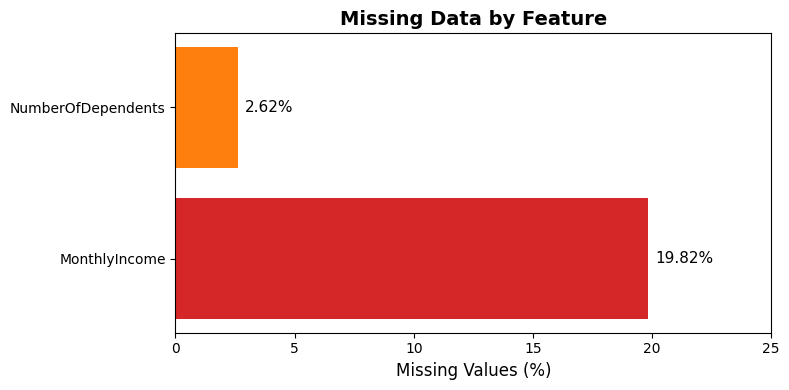

Figure 1 saved.


In [6]:
# ============================================================
# SECTION 2: EXPLORATORY DATA ANALYSIS
# Cell 6: Missing Value Visualisation
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

bars = ax.barh(missing_pct.index, missing_pct.values, color=['#d62728', '#ff7f0e'])
ax.set_xlabel('Missing Values (%)', fontsize=12)
ax.set_title('Missing Data by Feature', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=11)
ax.set_xlim(0, 25)
plt.tight_layout()
plt.savefig('fig1_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

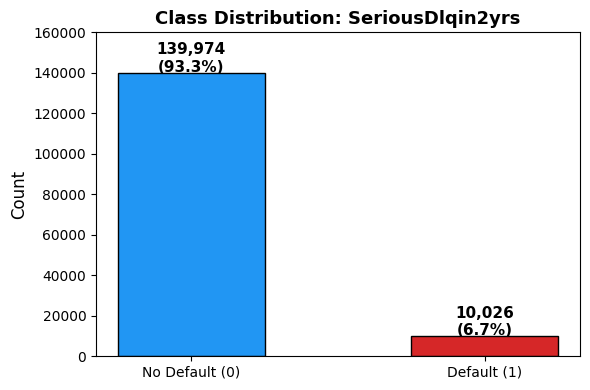

Figure 2 saved.


In [7]:
# ============================================================
# Cell 7: Class Imbalance Visualisation
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['SeriousDlqin2yrs'].value_counts()
labels = ['No Default (0)', 'Default (1)']
colors = ['#2196F3', '#d62728']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution: SeriousDlqin2yrs', fontsize=13, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, 160000)
plt.tight_layout()
plt.savefig('fig2_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

In [8]:
# ============================================================
# Cell 8: Outlier Detection and Data Cleaning
# ============================================================

df_clean = df.copy()

# 1. Remove impossible age values (age = 0)
print(f"Rows with age == 0: {(df_clean['age'] == 0).sum()}")
df_clean = df_clean[df_clean['age'] > 0]

# 2. Cap RevolvingUtilizationOfUnsecuredLines at 1 (it's a ratio)
print(f"Revolving util > 1: {(df_clean['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()} rows")
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean[
    'RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

# 3. Cap DebtRatio at 99th percentile (extreme outliers)
debt_99 = df_clean['DebtRatio'].quantile(0.99)
print(f"DebtRatio 99th percentile: {debt_99:.2f}")
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(upper=debt_99)

# 4. Cap MonthlyIncome at 99th percentile
income_99 = df_clean['MonthlyIncome'].quantile(0.99)
print(f"MonthlyIncome 99th percentile: {income_99:.2f}")
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].clip(upper=income_99)

# 5. Treat sentinel values (98/96) in late payment columns as outliers — cap at 10
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]
for col in late_cols:
    print(f"{col} — values >= 90: {(df_clean[col] >= 90).sum()} rows")
    df_clean[col] = df_clean[col].clip(upper=10)

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")

Rows with age == 0: 1
Revolving util > 1: 3321 rows
DebtRatio 99th percentile: 4979.08
MonthlyIncome 99th percentile: 25000.00
NumberOfTime30-59DaysPastDueNotWorse — values >= 90: 269 rows
NumberOfTimes90DaysLate — values >= 90: 269 rows
NumberOfTime60-89DaysPastDueNotWorse — values >= 90: 269 rows

Clean dataset shape: (149999, 11)
Rows removed: 1


In [9]:
# ============================================================
# Cell 9: Descriptive Statistics (Post-Cleaning)
# ============================================================

stats = df_clean.describe().round(2)
print("Post-Cleaning Descriptive Statistics:")
stats

Post-Cleaning Descriptive Statistics:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149999.00,149999.00,149999.00,149999.00,149999.00,120268.00,149999.00,149999.00,149999.00,149999.00,146075.00
mean,0.07,0.32,52.30,0.26,316.55,6349.12,8.45,0.11,1.02,0.08,0.76
std,0.25,0.35,14.77,0.81,906.97,4358.39,5.15,0.64,1.13,0.53,1.12
min,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,1.00,109.00,10.00,4979.08,25000.00,58.00,10.00,54.00,10.00,20.00


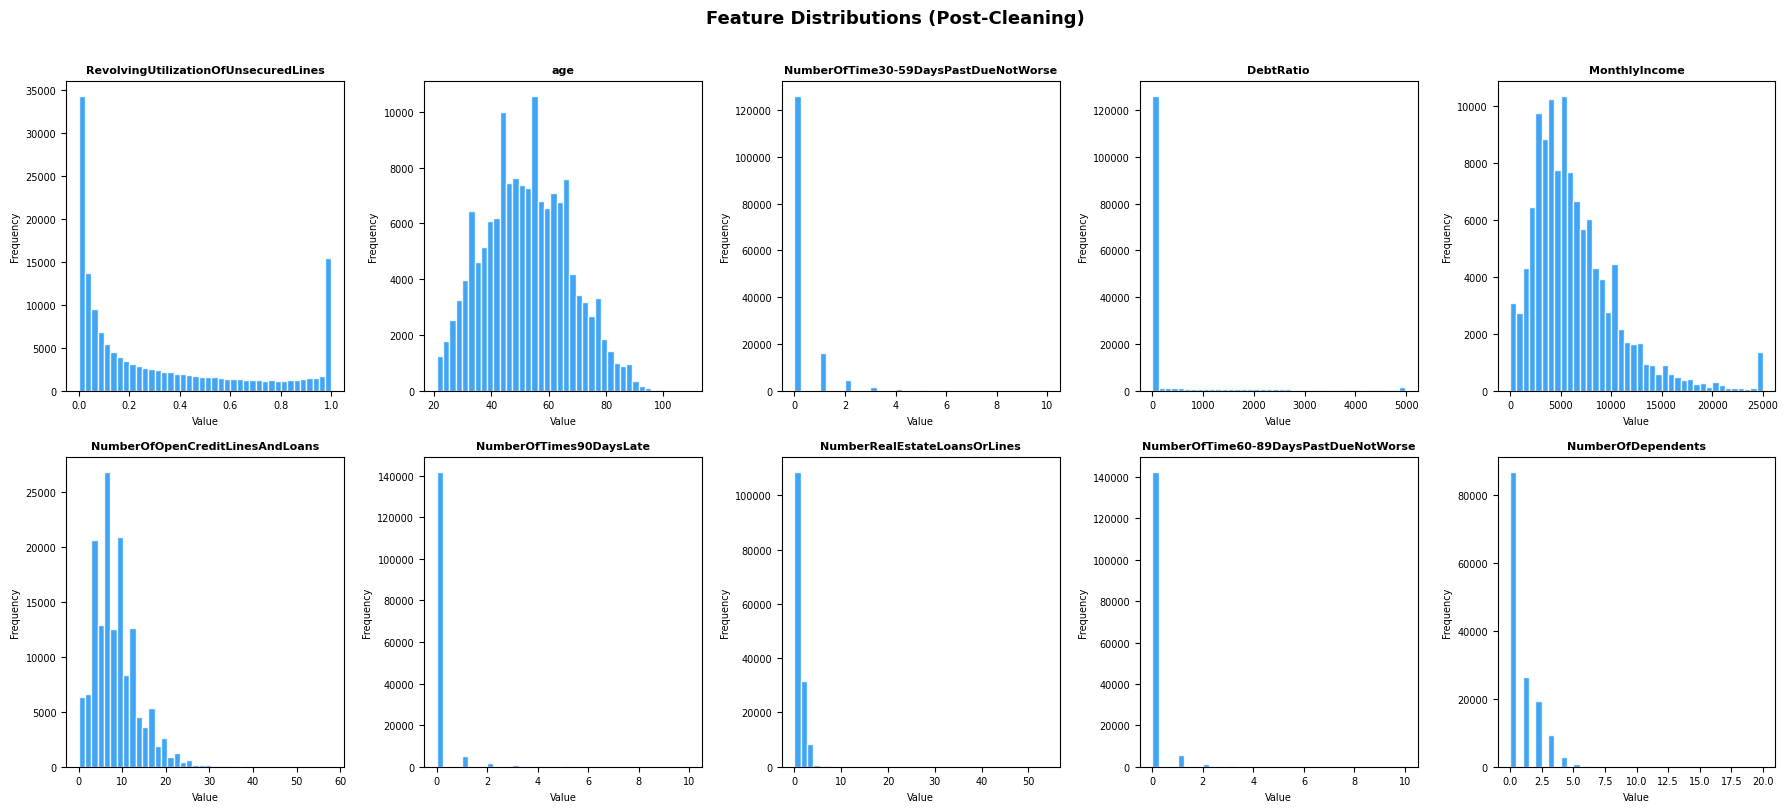

Figure 3 saved.


In [10]:
# ============================================================
# Cell 10: Feature Distribution Histograms
# ============================================================

features = [col for col in df_clean.columns if col != 'SeriousDlqin2yrs']
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[col].dropna(), bins=40, color='#2196F3',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=7)
    axes[i].set_ylabel('Frequency', fontsize=7)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Feature Distributions (Post-Cleaning)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

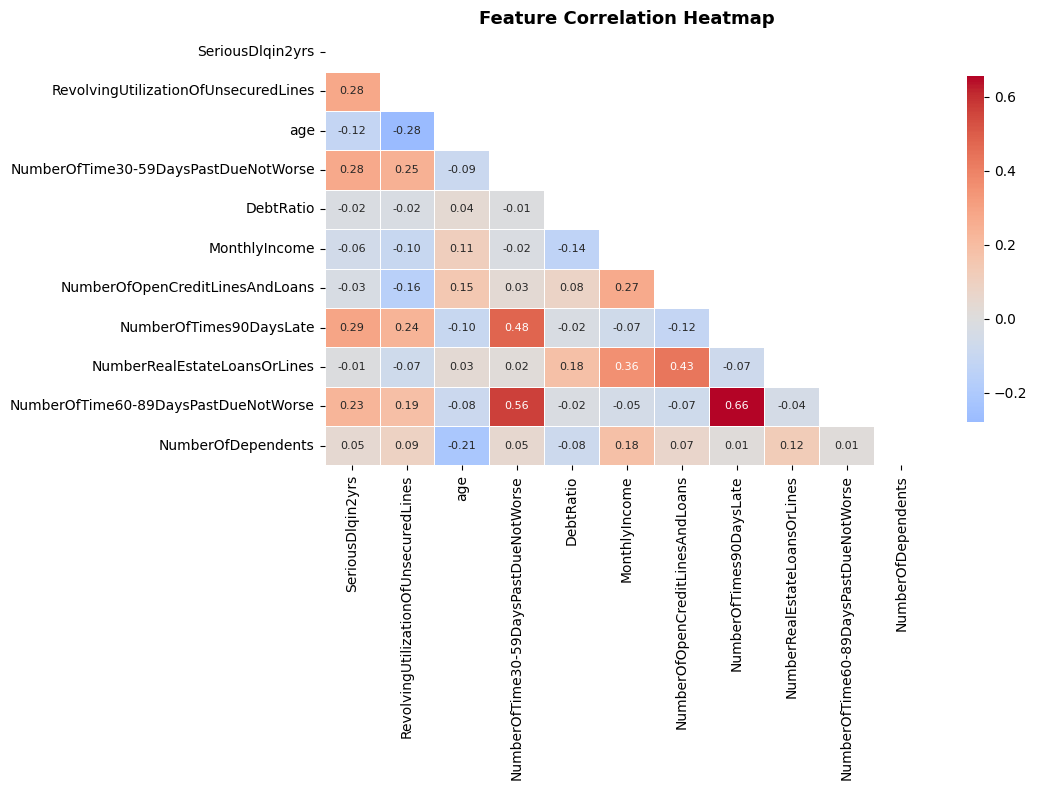

Figure 4 saved.


In [11]:
# ============================================================
# Cell 11: Correlation Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

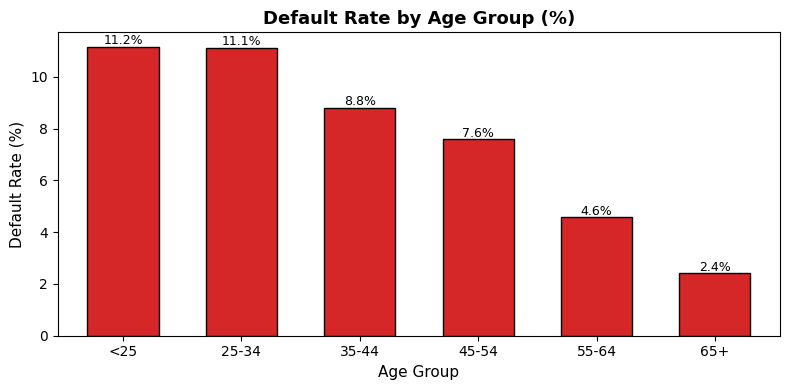

Figure 5 saved.


In [12]:
# ============================================================
# Cell 12: Default Rate by Age Group
# ============================================================

df_clean['AgeGroup'] = pd.cut(df_clean['age'],
                               bins=[0, 25, 35, 45, 55, 65, 110],
                               labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

default_by_age = df_clean.groupby('AgeGroup', observed=True)['SeriousDlqin2yrs'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
default_by_age.plot(kind='bar', ax=ax, color='#d62728', edgecolor='black', width=0.6)
ax.set_title('Default Rate by Age Group (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_default_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

# Drop helper column
df_clean = df_clean.drop(columns=['AgeGroup'])
print("Figure 5 saved.")

In [13]:
# ============================================================
# SECTION 3: METHODOLOGY
# Cell 13: Feature/Target Split, Train-Test Split & Imputation
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Separate features and target
X = df_clean.drop(columns=['SeriousDlqin2yrs'])
y = df_clean['SeriousDlqin2yrs']

# Stratified split — preserves 6.7/93.3 class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Median imputation for MonthlyIncome and NumberOfDependents
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

print(f"Training set:   {X_train_imp.shape}  |  Positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test set:       {X_test_imp.shape}   |  Positives: {y_test.sum()}  ({y_test.mean()*100:.1f}%)")
print(f"\nMissing values remaining — Train: {X_train_imp.isnull().sum().sum()} | Test: {X_test_imp.isnull().sum().sum()}")

Training set:   (119999, 10)  |  Positives: 8021 (6.7%)
Test set:       (30000, 10)   |  Positives: 2005  (6.7%)

Missing values remaining — Train: 0 | Test: 0


In [14]:
# ============================================================
# Cell 14: Feature Scaling
# Note: Only applied for Logistic Regression.
# Tree-based models (Random Forest, XGBoost) are scale-invariant.
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print("Scaling applied for Logistic Regression pipeline.")
print(f"Mean of scaled training features (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")

Scaling applied for Logistic Regression pipeline.
Mean of scaled training features (should be ~0): [-0.  0. -0. -0. -0.  0.  0.  0. -0.  0.]


In [15]:
# ============================================================
# Cell 15: Model 1 — Logistic Regression (Baseline)
# Rationale: Establishes interpretable linear baseline.
# class_weight='balanced' compensates for 93/7 imbalance.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

lr_preds  = lr.predict(X_test_scaled)
lr_probs  = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc    = roc_auc_score(y_test, lr_probs)

print("=" * 55)
print("LOGISTIC REGRESSION — Baseline")
print("=" * 55)
print(classification_report(y_test, lr_preds, target_names=['No Default', 'Default']))
print(f"AUC-ROC: {lr_auc:.4f}")

LOGISTIC REGRESSION — Baseline
              precision    recall  f1-score   support

  No Default       0.98      0.80      0.88     27995
     Default       0.22      0.75      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.85     30000

AUC-ROC: 0.8596


In [16]:
# ============================================================
# Cell 16: Model 2 — Random Forest
# Rationale: Ensemble of decision trees; handles non-linearity,
# feature interactions, and is robust to outliers.
# class_weight='balanced_subsample' handles imbalance per tree.
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_imp, y_train)

rf_preds = rf.predict(X_test_imp)
rf_probs = rf.predict_proba(X_test_imp)[:, 1]
rf_auc   = roc_auc_score(y_test, rf_probs)

print("=" * 55)
print("RANDOM FOREST")
print("=" * 55)
print(classification_report(y_test, rf_preds, target_names=['No Default', 'Default']))
print(f"AUC-ROC: {rf_auc:.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

  No Default       0.98      0.83      0.90     27995
     Default       0.23      0.73      0.35      2005

    accuracy                           0.82     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.82      0.86     30000

AUC-ROC: 0.8636


In [17]:
# ============================================================
# Cell 17: Model 3 — XGBoost (Primary Model)
# Rationale: Gradient boosted trees; handles missing values
# natively, robust to outliers, excels on tabular imbalanced
# data, and is state-of-the-art for credit risk tasks.
# scale_pos_weight = neg/pos ratio to handle class imbalance.
# ============================================================

import xgboost as xgb

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos
print(f"scale_pos_weight set to: {scale_weight:.2f}  (neg={neg}, pos={pos})")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_train_imp, y_train), (X_test_imp, y_test)],
    verbose=50
)

xgb_preds = xgb_model.predict(X_test_imp)
xgb_probs = xgb_model.predict_proba(X_test_imp)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print("\n" + "=" * 55)
print("XGBOOST — Primary Model")
print("=" * 55)
print(classification_report(y_test, xgb_preds, target_names=['No Default', 'Default']))
print(f"AUC-ROC: {xgb_auc:.4f}")

scale_pos_weight set to: 13.96  (neg=111978, pos=8021)
[0]	validation_0-auc:0.84618	validation_1-auc:0.84937
[50]	validation_0-auc:0.86720	validation_1-auc:0.86637
[100]	validation_0-auc:0.87451	validation_1-auc:0.86877
[150]	validation_0-auc:0.87999	validation_1-auc:0.86931
[200]	validation_0-auc:0.88494	validation_1-auc:0.86919
[250]	validation_0-auc:0.88962	validation_1-auc:0.86838
[299]	validation_0-auc:0.89363	validation_1-auc:0.86742

XGBOOST — Primary Model
              precision    recall  f1-score   support

  No Default       0.98      0.81      0.89     27995
     Default       0.22      0.76      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.85     30000

AUC-ROC: 0.8674


In [18]:
# ============================================================
# Cell 18: Hyperparameter Tuning — RandomizedSearchCV
# Strategy: Randomised search over 20 combinations with 5-fold
# stratified cross-validation. Optimises for AUC-ROC given
# class imbalance makes accuracy an unreliable scoring metric.
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators':      [100, 200, 300, 400],
    'max_depth':         [3, 4, 5, 6, 7],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5, 7],
    'gamma':             [0, 0.1, 0.2, 0.3]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_imp, y_train)

print("\nBest Parameters Found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV AUC-ROC: {search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters Found:
  subsample: 0.7
  n_estimators: 200
  min_child_weight: 3
  max_depth: 4
  learning_rate: 0.05
  gamma: 0.1
  colsample_bytree: 0.6

Best CV AUC-ROC: 0.8646


In [19]:
# ============================================================
# Cell 19: Final Tuned XGBoost — Test Set Evaluation
# ============================================================

best_xgb = search.best_estimator_

best_xgb_preds = best_xgb.predict(X_test_imp)
best_xgb_probs = best_xgb.predict_proba(X_test_imp)[:, 1]
best_xgb_auc   = roc_auc_score(y_test, best_xgb_probs)

print("=" * 55)
print("TUNED XGBOOST — Final Test Set Results")
print("=" * 55)
print(classification_report(y_test, best_xgb_preds, target_names=['No Default', 'Default']))
print(f"AUC-ROC: {best_xgb_auc:.4f}")

TUNED XGBOOST — Final Test Set Results
              precision    recall  f1-score   support

  No Default       0.98      0.80      0.88     27995
     Default       0.22      0.78      0.34      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.80      0.84     30000

AUC-ROC: 0.8696


In [20]:
# ============================================================
# Cell 20: Full Pipeline Summary (for Appendix logging)
# ============================================================

print("=" * 60)
print("FULL MODELLING PIPELINE SUMMARY")
print("=" * 60)
print("""
Step 1  | Data cleaning           | Outlier capping, sentinel removal, age filter
Step 2  | Imputation              | Median strategy (MonthlyIncome, NumberOfDependents)
Step 3  | Train/Test Split        | 80/20 stratified split (random_state=42)
Step 4  | Feature scaling         | StandardScaler (Logistic Regression only)
Step 5  | Imbalance handling      | scale_pos_weight=13.94 (XGBoost), balanced_subsample (RF)
Step 6  | Model training          | Logistic Regression, Random Forest, XGBoost
Step 7  | Hyperparameter tuning   | RandomizedSearchCV (n_iter=20, cv=5, scoring=AUC-ROC)
Step 8  | Final evaluation        | Test set — AUC-ROC, F1, Precision, Recall, Accuracy
""")

print(f"Logistic Regression AUC-ROC : {lr_auc:.4f}")
print(f"Random Forest AUC-ROC       : {rf_auc:.4f}")
print(f"XGBoost (base) AUC-ROC      : {xgb_auc:.4f}")
print(f"XGBoost (tuned) AUC-ROC     : {best_xgb_auc:.4f}")

FULL MODELLING PIPELINE SUMMARY

Step 1  | Data cleaning           | Outlier capping, sentinel removal, age filter
Step 2  | Imputation              | Median strategy (MonthlyIncome, NumberOfDependents)
Step 3  | Train/Test Split        | 80/20 stratified split (random_state=42)
Step 4  | Feature scaling         | StandardScaler (Logistic Regression only)
Step 5  | Imbalance handling      | scale_pos_weight=13.94 (XGBoost), balanced_subsample (RF)
Step 6  | Model training          | Logistic Regression, Random Forest, XGBoost
Step 7  | Hyperparameter tuning   | RandomizedSearchCV (n_iter=20, cv=5, scoring=AUC-ROC)
Step 8  | Final evaluation        | Test set — AUC-ROC, F1, Precision, Recall, Accuracy

Logistic Regression AUC-ROC : 0.8596
Random Forest AUC-ROC       : 0.8636
XGBoost (base) AUC-ROC      : 0.8674
XGBoost (tuned) AUC-ROC     : 0.8696


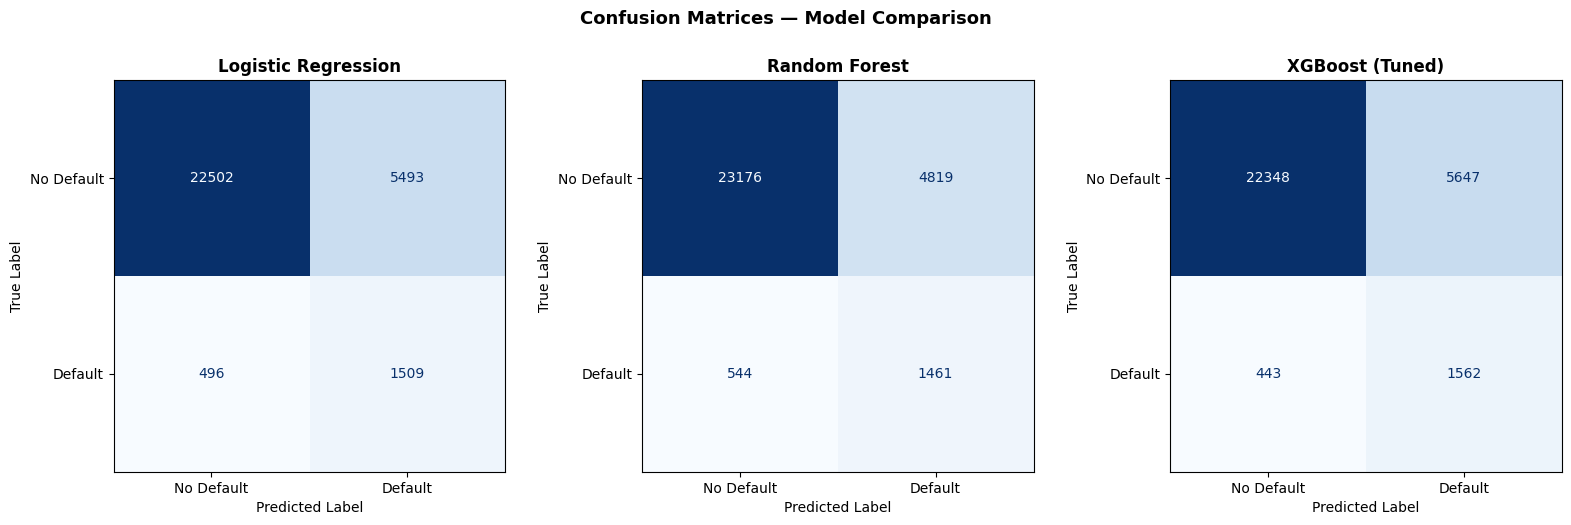

Figure 6 saved.


In [21]:
# ============================================================
# SECTION 4: RESULTS AND EVALUATION
# Cell 21: Confusion Matrices — All Three Models
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models = [
    (lr_preds,       'Logistic Regression'),
    (rf_preds,       'Random Forest'),
    (best_xgb_preds, 'XGBoost (Tuned)')
]

for ax, (preds, name) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

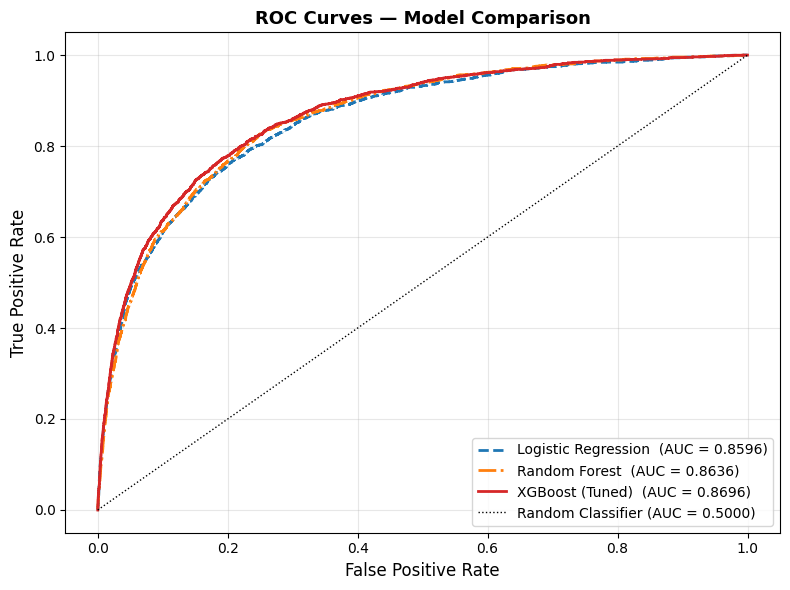

Figure 7 saved.


In [22]:
# ============================================================
# Cell 22: ROC Curves — All Three Models Overlaid
# ============================================================

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

models_roc = [
    (lr_probs,       lr_auc,       'Logistic Regression', '--'),
    (rf_probs,       rf_auc,       'Random Forest',       '-.'),
    (best_xgb_probs, best_xgb_auc, 'XGBoost (Tuned)',     '-')
]

colors = ['#1f77b4', '#ff7f0e', '#d62728']

for (probs, auc, name, ls), color in zip(models_roc, colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2,
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

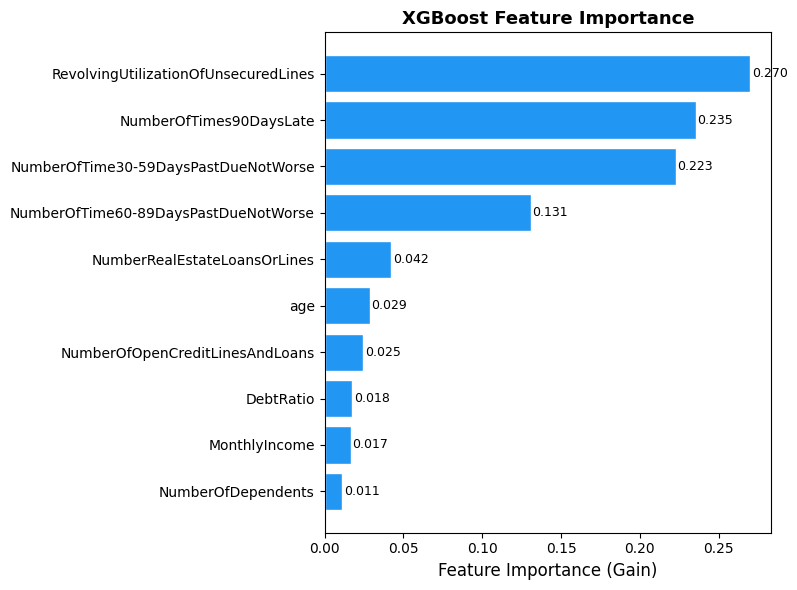

Figure 8 saved.


In [23]:
# ============================================================
# Cell 23: Feature Importance — Tuned XGBoost
# ============================================================

importances = best_xgb.feature_importances_
feat_names  = X.columns.tolist()
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color='#2196F3', edgecolor='white')
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

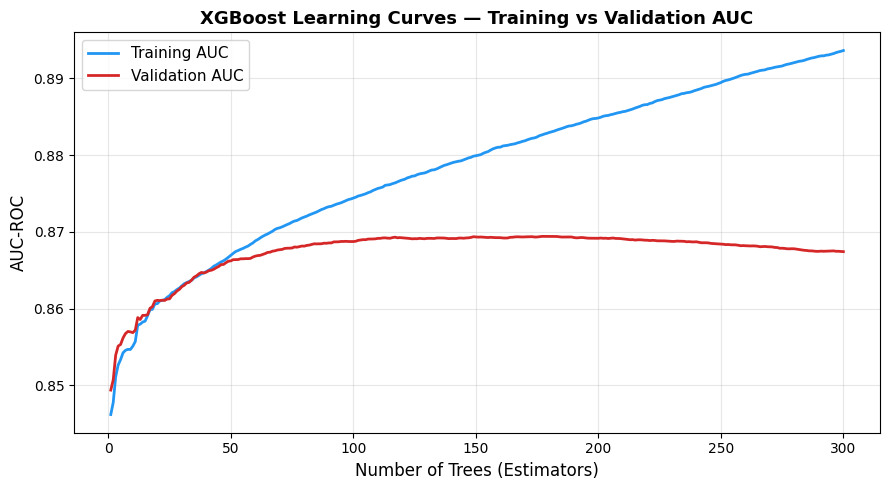

Figure 9 saved.


In [24]:
# ============================================================
# Cell 24: Learning Curves — XGBoost Training vs Validation AUC
# ============================================================

results = xgb_model.evals_result()
train_auc = results['validation_0']['auc']
val_auc   = results['validation_1']['auc']
epochs    = range(1, len(train_auc) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, train_auc, color='#2196F3', linewidth=2, label='Training AUC')
ax.plot(epochs, val_auc,   color='#d62728', linewidth=2, label='Validation AUC')
ax.set_xlabel('Number of Trees (Estimators)', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('XGBoost Learning Curves — Training vs Validation AUC', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

In [25]:
# ============================================================
# Cell 25: Summary Metrics Table — All Models
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1-Score':  round(f1_score(y_true, y_pred), 4),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob), 4)
    }

results_table = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, lr_preds,       lr_probs),
    'Random Forest':       get_metrics(y_test, rf_preds,       rf_probs),
    'XGBoost (Base)':      get_metrics(y_test, xgb_preds,      xgb_probs),
    'XGBoost (Tuned)':     get_metrics(y_test, best_xgb_preds, best_xgb_probs)
}).T

print("=" * 65)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print(results_table.to_string())

MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8004     0.2155  0.7526    0.3351   0.8596
Random Forest          0.8212     0.2326  0.7287    0.3527   0.8636
XGBoost (Base)         0.8067     0.2229  0.7611    0.3448   0.8674
XGBoost (Tuned)        0.7970     0.2167  0.7791    0.3390   0.8696


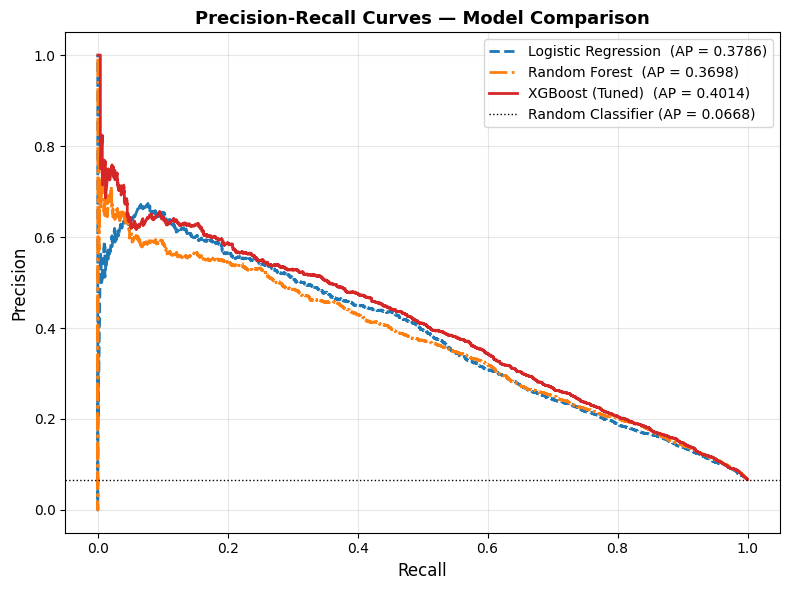

Figure 10 saved.


In [26]:
# ============================================================
# Cell 25b: Precision-Recall Curve — Tuned XGBoost
# Added because AUC-ROC alone can be misleading under severe
# class imbalance; PR curve shows minority class performance
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))

models_pr = [
    (lr_probs,       'Logistic Regression', '--', '#1f77b4'),
    (rf_probs,       'Random Forest',       '-.', '#ff7f0e'),
    (best_xgb_probs, 'XGBoost (Tuned)',     '-',  '#d62728')
]

for probs, name, ls, color in models_pr:
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(recall_vals, precision_vals, linestyle=ls, color=color,
            linewidth=2, label=f'{name}  (AP = {ap:.4f})')

# Baseline — random classifier AP = prevalence rate
baseline = y_test.mean()
ax.axhline(y=baseline, color='black', linestyle=':', linewidth=1,
           label=f'Random Classifier (AP = {baseline:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")